/tmp/ipykernel_8666/1438334444.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0,0], palette="Blues_d")


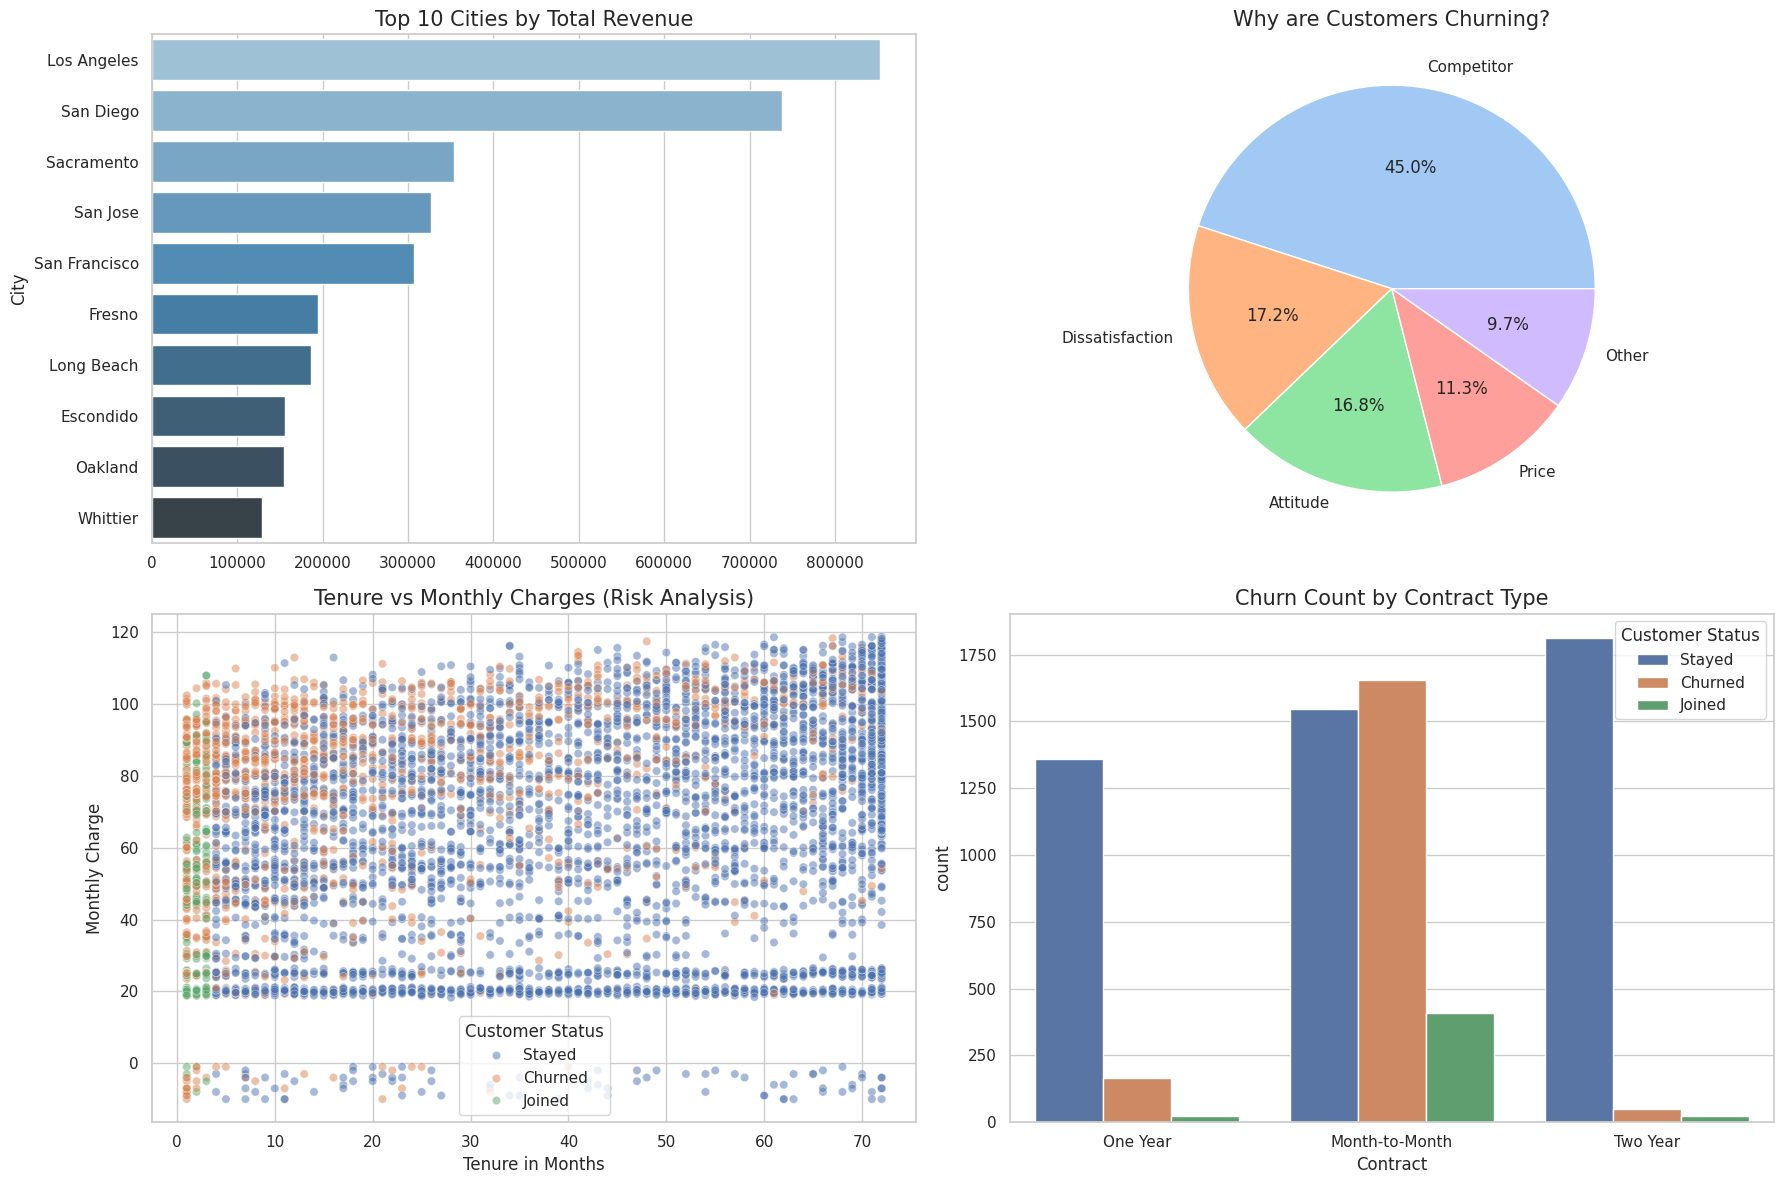

------------------------------
TOTAL REVENUE: $21,371,131.69
OVERALL CHURN RATE: 26.54%
AVERAGE POPULATION PER ZIP: 22,140
------------------------------


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('telecom_customer_churn.csv')
df_pop = pd.read_csv('telecom_zipcode_population.csv')
df = pd.merge(df, df_pop, on='Zip Code', how='left')


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))


top_cities = df.groupby('City')['Total Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0,0], palette="Blues_d")
axes[0,0].set_title('Top 10 Cities by Total Revenue', fontsize=15)


churn_reasons = df[df['Customer Status'] == 'Churned']['Churn Category'].value_counts()
axes[0,1].pie(churn_reasons, labels=churn_reasons.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
axes[0,1].set_title('Why are Customers Churning?', fontsize=15)


sns.scatterplot(data=df, x='Tenure in Months', y='Monthly Charge', hue='Customer Status', alpha=0.5, ax=axes[1,0])
axes[1,0].set_title('Tenure vs Monthly Charges (Risk Analysis)', fontsize=15)


sns.countplot(data=df, x='Contract', hue='Customer Status', ax=axes[1,1])
axes[1,1].set_title('Churn Count by Contract Type', fontsize=15)

plt.tight_layout()
plt.show()


print("-" * 30)
print(f"TOTAL REVENUE: ${df['Total Revenue'].sum():,.2f}")
print(f"OVERALL CHURN RATE: {(df['Customer Status'] == 'Churned').mean()*100:.2f}%")
print(f"AVERAGE POPULATION PER ZIP: {df['Population'].mean():,.0f}")
print("-" * 30)